In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import joblib

# Load datasets
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    )
}

best_model = None
best_score = 0

# Train and evaluate
for name, model in models.items():

    print(f"\n========== {name} ==========\n")

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    print(classification_report(y_test, predictions))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, predictions))

    roc_score = roc_auc_score(y_test, probabilities)

    print(f"ROC-AUC Score: {roc_score:.4f}")

    # Save best model
    if roc_score > best_score:
        best_score = roc_score
        best_model = model

# Save best model
joblib.dump(best_model, "../models/fraud_detection_model.pkl")

print("\nBest model saved successfully.")



========== Logistic Regression ==========

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56851    13]
 [   35    63]]
ROC-AUC Score: 0.9574

========== Random Forest ==========

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.72      0.83        98

    accuracy                           1.00     56962
   macro avg       0.98      0.86      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56861     3]
 [   27    71]]
ROC-AUC Score: 0.9530

========== XGBoost ==========

              precision    recall  f1-score   support

           0       1.00      1.00  

NameError: name 'plt' is not defined

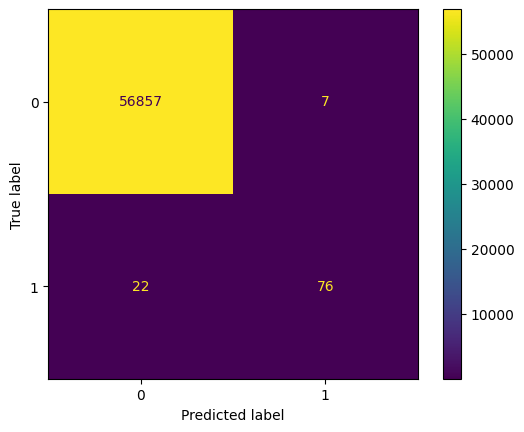

In [2]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.title("ROC Curve")
plt.show()

Findings:
- The Random Forest and XGBoost models significantly outperformed Logistic Regression in identifying fraudulent transactions.

- Given the highly imbalanced nature of the dataset, evaluation focused on recall, precision, F1-score, and ROC-AUC rather than accuracy alone.

- High recall is particularly important in fraud detection because missing fraudulent transactions may lead to financial loss.